# Relate immunoglobulin status to plasma-cell developmental potential

**Biology rationale.** Combining heavy- and light-chain status with CytoTRACE tests whether repertoire features align with differentiation state.

**Aim.** Integrate IgH/IgK/IgL metadata with single-cell data and compare CytoTRACE-related states.

**Data input.** `adata_dandelion.h5ad`, `metadata-productiveIgHstatus.csv`, `IGH_stacked_violin_side_by_side.pdf`, `heatmap_{group_col}_row_scaled.pdf`, `heatmap_{group_col}_raw_mean.pdf`



**Data outputs.** `dotplot_UPR_redblue_noTotals.pdf`, `subclone_igLdisease_over_GAPDH_boxplot_publication.pdf`, `subclone_igLdisease_over_GAPDH_boxplot_publication.png`, `Saved: clonotype_rotated_90deg_bar_right.pdf`

## 1. Packages and setup


In [1]:
import sys
import scanpy as sc
import scvelo as scv
import pandas as pd

In [3]:
import warnings

warnings.simplefilter("ignore", category=UserWarning)
sc.settings.set_figure_params(frameon=False, dpi=100)

In [4]:
adata = sc.read_h5ad('adata_dandelion.h5ad')

In [5]:
# --- inputs ---
meta_csv = "metadata-productiveIgHstatus.csv"
barcode_colname = "barcode"  # only used if your adata uses a barcode column instead of obs_names

# --- 1) read metadata: first column is barcode index (no column name) ---
meta = pd.read_csv(meta_csv, header=0, index_col=0)

# clean index just in case
meta.index = meta.index.astype(str).str.strip()

# --- NEW: harmonize naming convention in metadata index ---
# replace all "MM" -> "HPCAL"
old_index = meta.index
meta.index = meta.index.str.replace("MM", "HPCAL", regex=False)
n_changed = (old_index != meta.index).sum()
print(f"metadata index: replaced 'MM' -> 'HPCAL' for {n_changed} / {meta.shape[0]} rows")

# --- 2) decide what to match against in adata ---
# Prefer matching to adata.obs_names (recommended best practice).
adata_cell_index = adata.obs_names.astype(str)

# If your barcodes are stored in adata.obs["barcode"] and obs_names are something else, use this instead:
# adata_cell_index = adata.obs[barcode_colname].astype(str)

# --- 3) compute overlap and subset adata everywhere (safe for all slots) ---
common = adata_cell_index.intersection(meta.index)
print("adata n_obs:", adata.n_obs)
print("metadata rows:", meta.shape[0])
print("overlap:", common.size)

# If matching to obs_names:
adata = adata[common].copy()

# If matching to adata.obs["barcode"] instead, do:
# keep_mask = adata.obs[barcode_colname].astype(str).isin(common)
# adata = adata[keep_mask].copy()
# (then you'll likely want to set obs_names = barcode for clean alignment:)
# adata.obs_names = adata.obs[barcode_colname].astype(str)

# --- 4) align metadata to the (now subset) adata and merge into obs ---
meta_aligned = meta.reindex(adata.obs_names)

# Optional: avoid column name collisions
overlap_cols = adata.obs.columns.intersection(meta_aligned.columns)
if len(overlap_cols) > 0:
    meta_aligned = meta_aligned.rename(columns={c: f"{c}_meta" for c in overlap_cols})

# assign columns into obs
for c in meta_aligned.columns:
    adata.obs[c] = meta_aligned[c]

print("done. adata shape:", adata.shape)
print("new obs cols added:", list(meta.columns))


metadata index: replaced 'MM' -> 'HPCAL' for 21457 / 137567 rows
adata n_obs: 181834
metadata rows: 137567
overlap: 137567
done. adata shape: (137567, 36601)
new obs cols added: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ig', 'percent.hb', 'unintegrated_clusters', 'seurat_clusters', 'barcode', 'singlet', 'subtype', 'mutation', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'barcode.1', 'clonotype', 'orig.ident.1', 'barcode_IGL', 'raw_clonotype_id_IGL', 'barcode_IGH', 'raw_clonotype_id_IGH', 'productive_IGH_nonproductive', 'cdr3_IGH_nonproductive', 'ProductiveIgH_flag', 'NonproductiveIgH_flag', 'IgH_status', 'Usage_1', 'Usage_2', 'Usage_3', 'Usage_4', 'Usage_5', 'Usage_6', 'Usage_7', 'Usage_8', 'Usage_9', 'Usage_10', 'Usage_11', 'Usage_12', 'Usage_13', 'cnv_score', 'percent.igL', 'percent.igH']


In [6]:
import re
import numpy as np
import pandas as pd
import scipy.sparse as sp

# ---------------------------------------
# settings
# ---------------------------------------
sample_col = "orig.ident"   # change if your sample column has another name
out_col = "percent.igLdisease"

# ---------------------------------------
# helper
# ---------------------------------------
def _to_1d(x):
    if sp.issparse(x):
        x = x.toarray()
    x = np.asarray(x)
    return x.ravel()

# ---------------------------------------
# gene names
# ---------------------------------------
genes = pd.Index(adata.var_names.astype(str))

# initialize output
adata.obs[out_col] = np.nan

# total counts per cell
if "total_counts" in adata.obs.columns:
    total_counts = adata.obs["total_counts"].to_numpy()
else:
    total_counts = _to_1d(adata.X.sum(axis=1))

# store chosen dominant gene for each sample
dominant_gene_by_sample = {}

# ---------------------------------------
# loop over samples
# ---------------------------------------
for sample in adata.obs[sample_col].astype(str).unique():
    cell_idx = np.where(adata.obs[sample_col].astype(str).to_numpy() == sample)[0]
    if len(cell_idx) == 0:
        continue

    # decide whether this sample is kappa or lambda disease
    if sample.startswith("ALk"):
        pattern = r"(?i)^IGKV"
    elif sample.startswith("ALl"):
        pattern = r"(?i)^IGLV"
    elif sample.startswith("HPCAL1"):
        pattern = r"(?i)^IGLV"
    elif sample.startswith("HPCAL2"):
        pattern = r"(?i)^IGKV"
    elif sample.startswith("HPCAL3"):
        pattern = r"(?i)^IGLV"
    else:
        print(f"[skip] sample {sample} does not start with ALk or ALl")
        continue

    # genes matching this sample's disease light chain
    matched_genes = genes[genes.str.match(pattern, na=False)]
    if len(matched_genes) == 0:
        print(f"[skip] no genes found for {sample} with pattern {pattern}")
        continue

    gene_idx = genes.get_indexer(matched_genes)

    # subset matrix: cells in this sample × matched genes
    X_sub = adata.X[cell_idx][:, gene_idx]

    # sum expression across all cells in this sample for each matched gene
    gene_sums = _to_1d(X_sub.sum(axis=0))

    # choose the highestly expressed disease light-chain gene in this sample
    best_gene_pos = int(np.argmax(gene_sums))
    best_gene = matched_genes[best_gene_pos]
    dominant_gene_by_sample[sample] = best_gene

    print(f"[sample={sample}] dominant disease LC gene = {best_gene}")

    # get per-cell counts for that dominant gene
    best_gene_global_idx = genes.get_loc(best_gene)
    gene_counts = _to_1d(adata.X[cell_idx, best_gene_global_idx])

    # percent of total counts
    pct = np.divide(
        gene_counts,
        total_counts[cell_idx],
        out=np.zeros_like(gene_counts, dtype=float),
        where=total_counts[cell_idx] != 0
    ) * 100

    adata.obs.iloc[cell_idx, adata.obs.columns.get_loc(out_col)] = pct

# optional: save dominant gene info
adata.uns["dominant_igL_disease_gene_by_sample"] = dominant_gene_by_sample

[sample=ALl14plasma] dominant disease LC gene = IGLV1-51
[sample=ALk5plasma] dominant disease LC gene = IGKV4-1
[sample=ALk1preplasma] dominant disease LC gene = IGKV1-27
[sample=ALl13plasma] dominant disease LC gene = IGLV3-21
[sample=HPCAL3plasma] dominant disease LC gene = IGLV3-21
[sample=ALl8preplasma] dominant disease LC gene = IGLV3-1
[sample=ALl7preplasma] dominant disease LC gene = IGLV2-14
[sample=ALl9preplasma] dominant disease LC gene = IGLV2-14
[sample=ALk2plasma] dominant disease LC gene = IGKV1D-12
[sample=ALl4preplasma] dominant disease LC gene = IGLV3-1
[sample=ALl5preplasma] dominant disease LC gene = IGLV6-57
[sample=HPCAL1plasma] dominant disease LC gene = IGLV2-14
[sample=HPCAL2plasma] dominant disease LC gene = IGKV1D-33
[sample=ALl6preplasma] dominant disease LC gene = IGLV3-1
[sample=ALl15plasma] dominant disease LC gene = IGLV3-1
[sample=ALl3preplasma] dominant disease LC gene = IGLV6-57
[sample=ALk3preplasma] dominant disease LC gene = IGKV1D-33
[sample=ALk4pl

## 2. Visualization and figure generation


In [9]:
import pandas as pd

col = "IgH_status"
new_label = "None_IgH"   # 你想要的名字（建议用这个，和你前面一致）

s = adata.obs[col]

if pd.api.types.is_categorical_dtype(s):
    if new_label not in s.cat.categories:
        adata.obs[col] = s.cat.add_categories([new_label])

adata.obs[col] = adata.obs[col].fillna(new_label)
adata.obs[col] = adata.obs[col].replace("None", new_label)

if pd.api.types.is_categorical_dtype(adata.obs[col]):
    adata.obs[col] = adata.obs[col].cat.remove_unused_categories()

print(adata.obs[col].value_counts(dropna=False))


IgH_status
ProductiveIgH       68509
None_IgH            66445
NonproductiveIgH     1831
Both                  782
Name: count, dtype: int64


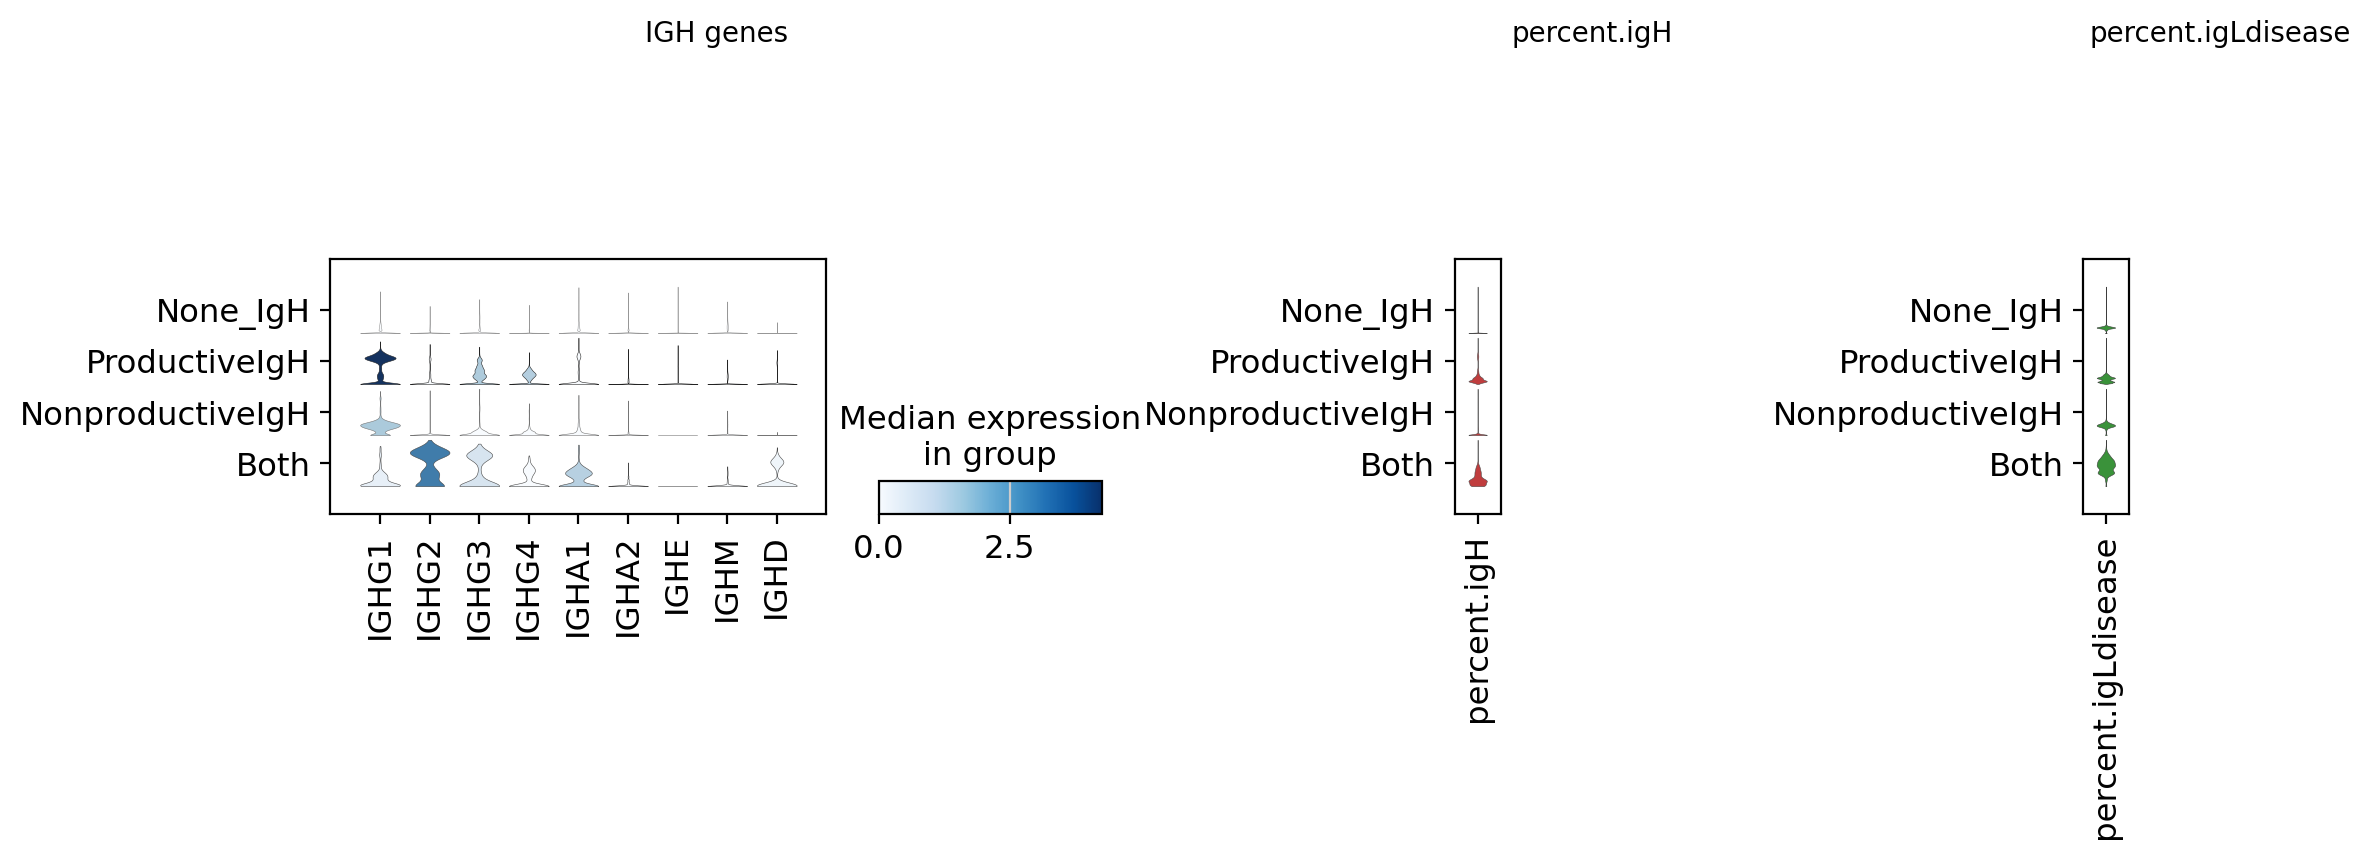

In [24]:
import numpy as np
import pandas as pd
import scanpy as sc
from anndata import AnnData
import matplotlib.pyplot as plt

GROUP = "IgH_status"

genes = ["IGHG1","IGHG2","IGHG3","IGHG4","IGHA1","IGHA2","IGHE","IGHM","IGHD"]
order = ["None_IgH", "ProductiveIgH", "NonproductiveIgH", "Both"]

adata.obs[GROUP] = adata.obs[GROUP].astype(str).str.strip()
adata.obs[GROUP] = pd.Categorical(adata.obs[GROUP], categories=order, ordered=True)

if f"{GROUP}_colors" not in adata.uns:
    raise ValueError(
        f"adata.uns['{GROUP}_colors'] not found. "
        f"Run a plot once (e.g. sc.pl.umap(..., color='{GROUP}')) to initialize colors."
    )

colors_arr = list(adata.uns[f"{GROUP}_colors"])
cats_now = list(adata.obs[GROUP].cat.categories)
if len(colors_arr) != len(cats_now):
    raise ValueError(
        f"Color array length ({len(colors_arr)}) != #categories ({len(cats_now)})."
    )

cat2color = dict(zip(cats_now, colors_arr))
group_palette = [cat2color[c] for c in cats_now]

# -------- genes --------
present_genes = [g for g in genes if g in adata.var_names]
if len(present_genes) == 0:
    raise ValueError("None of the requested IGH genes are present in adata.var_names.")

G = adata[:, present_genes].X
G = G.toarray() if hasattr(G, "toarray") else np.asarray(G)

tmpG = AnnData(
    X=G,
    obs=adata.obs[[GROUP]].copy(),
    var=pd.DataFrame(index=present_genes),
)
tmpG.uns[f"{GROUP}_colors"] = group_palette

# -------- percent.igH --------
if "percent.igH" not in adata.obs.columns:
    raise ValueError("percent.igH not found in adata.obs")

tmpH = AnnData(
    X=adata.obs[["percent.igH"]].to_numpy(dtype=float),
    obs=adata.obs[[GROUP]].copy(),
    var=pd.DataFrame(index=["percent.igH"]),
)
tmpH.uns[f"{GROUP}_colors"] = group_palette

# -------- percent.igLdisease --------
if "percent.igLdisease" not in adata.obs.columns:
    raise ValueError("percent.igLdisease not found in adata.obs")

tmpL = AnnData(
    X=adata.obs[["percent.igLdisease"]].to_numpy(dtype=float),
    obs=adata.obs[[GROUP]].copy(),
    var=pd.DataFrame(index=["percent.igLdisease"]),
)
tmpL.uns[f"{GROUP}_colors"] = group_palette

# -------- plot --------
fig, axs = plt.subplots(
    1, 3, figsize=(13, 3),
    gridspec_kw={"wspace": 0.8, "width_ratios": [2.8, 1, 1]}
)

# Panel 1: IGH genes
sc.pl.stacked_violin(
    tmpG,
    var_names=present_genes,
    groupby=GROUP,
    stripplot=False,
    jitter=False,
    ax=axs[0],
    show=False,
)
axs[0].set_title("IGH genes", fontsize=10)

# Panel 2: percent.igH only, red
sc.pl.stacked_violin(
    tmpH,
    var_names=["percent.igH"],
    groupby=GROUP,
    stripplot=False,
    jitter=False,
    row_palette=["tab:red"],
    ax=axs[1],
    show=False,
)
axs[1].set_title("percent.igH", fontsize=10)

# Panel 3: percent.igLdisease only, green
sc.pl.stacked_violin(
    tmpL,
    var_names=["percent.igLdisease"],
    groupby=GROUP,
    stripplot=False,
    jitter=False,
    row_palette=["tab:green"],
    ax=axs[2],
    show=False,
)
axs[2].set_title("percent.igLdisease", fontsize=10)

plt.tight_layout()
plt.show()

In [28]:
fig.savefig(
    "IGH_stacked_violin_side_by_side.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

## 3. USER SETTINGS


In [32]:
import os
import re
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# =========================================================
# USER SETTINGS
# =========================================================
HALLMARK_GMT = "./h.all.v2026.1.Hs.symbols.gmt"
GOBP_GMT     = "./c5.go.bp.v2026.1.Hs.symbols.gmt"

HALLMARK_KEYWORDS = ["Endoplasmic Reticulum Response","Endoplasmic Reticulum Stress","Unfold","Amyloid fibril formation","Amyloid precursor protein","ATF4"]
GO_BP_KEYWORDS    = ["Endoplasmic Reticulum Response","Endoplasmic Reticulum Stress","Unfold","Amyloid fibril formation","Amyloid precursor protein","ATF4"]


MIN_GENES_IN_ADATA = 5
USE_RAW = False
SCORE_SUFFIX = "_score"

OUTDIR = "gene_set_scores_human_heatmaps"
os.makedirs(OUTDIR, exist_ok=True)

HEATMAP_CMAP = "magma"   # or "viridis"
ROW_SCALE = True
MIN_CELLS_PER_GROUP = 3

GROUPINGS_TO_PLOT = [
    "orig.ident",
    "IgH_status",
    "clonotype",
    "sample_clonotype",
    "sample_clonotype_group",
]

IGH_ORDER = ["None_IgH", "ProductiveIgH", "NonproductiveIgH", "Both"]

# =========================================================
# GMT parser: no gseapy needed
# =========================================================
def read_gmt(gmt_file):
    """
    Parse a GMT file into:
      {gene_set_name: [gene1, gene2, ...]}
    GMT format:
      col1 = set name
      col2 = description
      col3+ = genes
    """
    out = {}
    with open(gmt_file, "r", encoding="utf-8", errors="ignore") as f:
        for line_num, line in enumerate(f, start=1):
            line = line.rstrip("\n\r")
            if not line.strip():
                continue
            parts = line.split("\t")
            if len(parts) < 3:
                print(f"[warn] skipping malformed line {line_num} in {gmt_file}")
                continue
            set_name = parts[0].strip()
            genes = [g.strip() for g in parts[2:] if g.strip() != ""]
            if len(genes) == 0:
                continue
            out[set_name] = genes
    return out

def validate_gmt_not_html(gmt_file, n_lines=3):
    """
    Quick check that file is not an HTML login page.
    """
    with open(gmt_file, "r", encoding="utf-8", errors="ignore") as f:
        head = "".join([next(f, "") for _ in range(n_lines)]).lower()
    if "<html" in head or "<!doctype html" in head:
        raise ValueError(
            f"{gmt_file} looks like HTML, not a GMT file. "
            "The download likely returned a login/redirect page."
        )

# =========================================================
# Sanity
# =========================================================
adata.var_names = pd.Index(adata.var_names.astype(str))
adata.var_names_make_unique()
var_names = set(adata.var_names)

print(f"[OK] n_obs={adata.n_obs:,}, n_vars={adata.n_vars:,}")

# optional metadata cleanup
for col in ["orig.ident", "clonotype", "IgH_status"]:
    if col in adata.obs.columns:
        adata.obs[col] = adata.obs[col].astype("object")

if "orig.ident" in adata.obs.columns:
    adata.obs["orig.ident"] = adata.obs["orig.ident"].astype(str)

if "clonotype" in adata.obs.columns:
    bad_clone = (
        adata.obs["clonotype"].isna()
        | adata.obs["clonotype"].astype(str).isin(["", "nan", "None", "NA"])
    )
    adata.obs.loc[~bad_clone, "clonotype"] = adata.obs.loc[~bad_clone, "clonotype"].astype(str)

if "IgH_status" in adata.obs.columns:
    adata.obs["IgH_status"] = adata.obs["IgH_status"].replace({
        "": np.nan, "nan": np.nan, "None": np.nan, "NA": np.nan
    })

if "orig.ident" in adata.obs.columns and "clonotype" in adata.obs.columns:
    valid_clone = (
        adata.obs["clonotype"].notna()
        & ~adata.obs["clonotype"].astype(str).isin(["", "nan", "None", "NA"])
    )
    adata.obs["sample_clonotype"] = np.nan
    adata.obs.loc[valid_clone, "sample_clonotype"] = (
        adata.obs.loc[valid_clone, "orig.ident"].astype(str)
        + " | "
        + adata.obs.loc[valid_clone, "clonotype"].astype(str)
    )

if all(c in adata.obs.columns for c in ["orig.ident", "clonotype", "IgH_status"]):
    valid_all = (
        adata.obs["clonotype"].notna()
        & adata.obs["IgH_status"].notna()
        & ~adata.obs["clonotype"].astype(str).isin(["", "nan", "None", "NA"])
    )
    adata.obs["sample_clonotype_group"] = np.nan
    adata.obs.loc[valid_all, "sample_clonotype_group"] = (
        adata.obs.loc[valid_all, "orig.ident"].astype(str)
        + " | "
        + adata.obs.loc[valid_all, "clonotype"].astype(str)
        + " | "
        + adata.obs.loc[valid_all, "IgH_status"].astype(str)
    )

# =========================================================
# Load GMTs without gseapy
# =========================================================
validate_gmt_not_html(HALLMARK_GMT)
validate_gmt_not_html(GOBP_GMT)

hallmark_all = read_gmt(HALLMARK_GMT)
gobp_all     = read_gmt(GOBP_GMT)

print(f"[INFO] Loaded GMTs: hallmark={len(hallmark_all):,}, go_bp={len(gobp_all):,}")

# =========================================================
# Filter GMTs by keyword
# =========================================================
def filter_gmt_by_keywords(gmt_dict, keywords):
    if not keywords:
        return {}
    kws = [k.lower() for k in keywords]
    out = {}
    for term, genes in gmt_dict.items():
        term_l = str(term).lower()
        if any(k in term_l for k in kws):
            out[term] = genes
    return out

hallmark_hit = filter_gmt_by_keywords(hallmark_all, HALLMARK_KEYWORDS)
gobp_hit     = filter_gmt_by_keywords(gobp_all, GO_BP_KEYWORDS)

print(f"[INFO] Hallmark keyword-hit={len(hallmark_hit)}")
print(f"[INFO] GO:BP keyword-hit={len(gobp_hit)}")

# =========================================================
# Score gene sets
# =========================================================
def score_gmt_dict(
    adata,
    gmt_dict,
    var_names_set,
    prefix=None,
    min_genes_in_adata=5,
    use_raw=False,
    score_suffix="_score",
    store_key="gene_set_scores",
):
    if store_key not in adata.uns:
        adata.uns[store_key] = {}

    added, skipped = [], []

    for set_name, genes in gmt_dict.items():
        base_name = str(set_name)
        if prefix:
            base_name = f"{prefix}{base_name}"

        safe = re.sub(r"[^0-9A-Za-z_]+", "_", base_name).strip("_")
        score_name = f"{safe}{score_suffix}"

        genes_in = [g for g in genes if g in var_names_set]
        if len(genes_in) < min_genes_in_adata:
            skipped.append((set_name, len(genes_in)))
            continue

        sc.tl.score_genes(
            adata,
            gene_list=genes_in,
            score_name=score_name,
            use_raw=use_raw,
        )

        adata.uns[store_key][score_name] = {
            "source_set": str(set_name),
            "prefix": prefix,
            "n_genes_in_adata": int(len(genes_in)),
        }
        added.append(score_name)

    return added, skipped

added_h, skipped_h = score_gmt_dict(
    adata,
    hallmark_hit,
    var_names_set=var_names,
    prefix="HALLMARK_",
    min_genes_in_adata=MIN_GENES_IN_ADATA,
    use_raw=USE_RAW,
    score_suffix=SCORE_SUFFIX,
)

added_go, skipped_go = score_gmt_dict(
    adata,
    gobp_hit,
    var_names_set=var_names,
    prefix="GO_BP_",
    min_genes_in_adata=MIN_GENES_IN_ADATA,
    use_raw=USE_RAW,
    score_suffix=SCORE_SUFFIX,
)

created = added_h + added_go

print(f"[OK] Scored: hallmark={len(added_h)} (skipped {len(skipped_h)}), GO:BP={len(added_go)} (skipped {len(skipped_go)})")
print(f"[INFO] Total created score cols: {len(created)}")

if len(created) == 0:
    raise RuntimeError("No gene sets matched and passed MIN_GENES_IN_ADATA.")

# =========================================================
# Heatmap helpers
# =========================================================
def row_zscore(df):
    row_mean = df.mean(axis=1)
    row_std = df.std(axis=1).replace(0, np.nan)
    return df.sub(row_mean, axis=0).div(row_std, axis=0).fillna(0.0)

def make_group_heatmap(
    adata,
    group_col,
    score_cols,
    outdir,
    cmap="magma",
    row_scale=True,
    min_cells_per_group=1,
    group_order=None,
):
    if group_col not in adata.obs.columns:
        print(f"[skip] {group_col} not found in adata.obs")
        return None

    df = adata.obs[[group_col] + score_cols].copy()
    df[group_col] = df[group_col].astype("object")
    df[group_col] = df[group_col].replace({
        "": np.nan, "nan": np.nan, "None": np.nan, "NA": np.nan
    })
    df = df.loc[df[group_col].notna()].copy()

    if df.empty:
        print(f"[skip] no valid cells for {group_col}")
        return None

    df[group_col] = df[group_col].astype(str)

    counts = df[group_col].value_counts()
    keep = counts[counts >= min_cells_per_group].index.tolist()
    df = df.loc[df[group_col].isin(keep)].copy()

    if df.empty:
        print(f"[skip] no groups pass min_cells_per_group for {group_col}")
        return None

    mean_mat = df.groupby(group_col)[score_cols].mean()

    if group_order is not None:
        present = [x for x in group_order if x in mean_mat.index]
        remaining = [x for x in mean_mat.index if x not in present]
        mean_mat = mean_mat.reindex(present + remaining)

    heat = mean_mat.T  # rows=gene sets, cols=groups

    if row_scale:
        heat_plot = row_zscore(heat)
        title = f"{group_col}: gene-set scores (row z-score)"
        outfile = os.path.join(outdir, f"heatmap_{group_col}_row_scaled.pdf")
    else:
        heat_plot = heat.copy()
        title = f"{group_col}: mean gene-set scores"
        outfile = os.path.join(outdir, f"heatmap_{group_col}_raw_mean.pdf")

    fig_w = max(6, 0.8 * heat_plot.shape[1])
    fig_h = max(6, 0.22 * heat_plot.shape[0])

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(heat_plot.values, aspect="auto", cmap=cmap)

    ax.set_yticks(np.arange(heat_plot.shape[0]))
    ax.set_yticklabels(heat_plot.index.tolist(), fontsize=7)

    ax.set_xticks(np.arange(heat_plot.shape[1]))
    ax.set_xticklabels(heat_plot.columns.tolist(), rotation=90, ha="center", fontsize=8)

    ax.set_xlabel(group_col)
    ax.set_ylabel("Gene set")
    ax.set_title(title)

    cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    cbar.ax.tick_params(labelsize=9)

    fig.tight_layout()
    fig.savefig(outfile, bbox_inches="tight")
    plt.close(fig)

    print(f"[OK] saved: {outfile}")
    return heat_plot

# =========================================================
# Make heatmaps
# =========================================================
for g in GROUPINGS_TO_PLOT:
    order_use = IGH_ORDER if g == "IgH_status" else None
    min_cells = MIN_CELLS_PER_GROUP if g in ["clonotype", "sample_clonotype", "sample_clonotype_group"] else 1

    make_group_heatmap(
        adata=adata,
        group_col=g,
        score_cols=created,
        outdir=OUTDIR,
        cmap=HEATMAP_CMAP,
        row_scale=ROW_SCALE,
        min_cells_per_group=min_cells,
        group_order=order_use,
    )

print(f"[DONE] all heatmaps saved in: {OUTDIR}")

[OK] n_obs=137,567, n_vars=36,601
[INFO] Loaded GMTs: hallmark=50, go_bp=7,538
[INFO] Hallmark keyword-hit=1
[INFO] GO:BP keyword-hit=13
[OK] Scored: hallmark=1 (skipped 0), GO:BP=13 (skipped 0)
[INFO] Total created score cols: 14
[OK] saved: gene_set_scores_human_heatmaps/heatmap_orig.ident_row_scaled.pdf
[OK] saved: gene_set_scores_human_heatmaps/heatmap_IgH_status_row_scaled.pdf
[OK] saved: gene_set_scores_human_heatmaps/heatmap_clonotype_row_scaled.pdf
[OK] saved: gene_set_scores_human_heatmaps/heatmap_sample_clonotype_row_scaled.pdf
[OK] saved: gene_set_scores_human_heatmaps/heatmap_sample_clonotype_group_row_scaled.pdf
[DONE] all heatmaps saved in: gene_set_scores_human_heatmaps


In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
from anndata import AnnData
import matplotlib.pyplot as plt

GROUP = "IgH_status"

genes = [XBP1 (spliced)

HSPA5 (BiP)

PDIA4 / PDIA6

ATF6 targets

    
]
order = ["None_IgH", "ProductiveIgH", "NonproductiveIgH", "Both"]

adata.obs[GROUP] = adata.obs[GROUP].astype(str).str.strip()
adata.obs[GROUP] = pd.Categorical(adata.obs[GROUP], categories=order, ordered=True)

if f"{GROUP}_colors" not in adata.uns:
    raise ValueError(
        f"adata.uns['{GROUP}_colors'] not found. "
        f"Run a plot once (e.g. sc.pl.umap(..., color='{GROUP}')) to initialize colors."
    )

colors_arr = list(adata.uns[f"{GROUP}_colors"])
cats_now = list(adata.obs[GROUP].cat.categories)
if len(colors_arr) != len(cats_now):
    raise ValueError(
        f"Color array length ({len(colors_arr)}) != #categories ({len(cats_now)})."
    )

cat2color = dict(zip(cats_now, colors_arr))
group_palette = [cat2color[c] for c in cats_now]

# -------- genes --------
present_genes = [g for g in genes if g in adata.var_names]
if len(present_genes) == 0:
    raise ValueError("None of the requested IGH genes are present in adata.var_names.")

G = adata[:, present_genes].X
G = G.toarray() if hasattr(G, "toarray") else np.asarray(G)

tmpG = AnnData(
    X=G,
    obs=adata.obs[[GROUP]].copy(),
    var=pd.DataFrame(index=present_genes),
)
tmpG.uns[f"{GROUP}_colors"] = group_palette

# -------- percent.igH --------
if "percent.igH" not in adata.obs.columns:
    raise ValueError("percent.igH not found in adata.obs")

tmpH = AnnData(
    X=adata.obs[["percent.igH"]].to_numpy(dtype=float),
    obs=adata.obs[[GROUP]].copy(),
    var=pd.DataFrame(index=["percent.igH"]),
)
tmpH.uns[f"{GROUP}_colors"] = group_palette

# -------- percent.igLdisease --------
if "percent.igLdisease" not in adata.obs.columns:
    raise ValueError("percent.igLdisease not found in adata.obs")

tmpL = AnnData(
    X=adata.obs[["percent.igLdisease"]].to_numpy(dtype=float),
    obs=adata.obs[[GROUP]].copy(),
    var=pd.DataFrame(index=["percent.igLdisease"]),
)
tmpL.uns[f"{GROUP}_colors"] = group_palette

# -------- plot --------
fig, axs = plt.subplots(
    1, 3, figsize=(13, 3),
    gridspec_kw={"wspace": 0.8, "width_ratios": [2.8, 1, 1]}
)

# Panel 1: IGH genes
sc.pl.stacked_violin(
    tmpG,
    var_names=present_genes,
    groupby=GROUP,
    stripplot=False,
    jitter=False,
    ax=axs[0],
    show=False,
)
axs[0].set_title("IGH genes", fontsize=10)

# Panel 2: percent.igH only, red
sc.pl.stacked_violin(
    tmpH,
    var_names=["percent.igH"],
    groupby=GROUP,
    stripplot=False,
    jitter=False,
    row_palette=["tab:red"],
    ax=axs[1],
    show=False,
)
axs[1].set_title("percent.igH", fontsize=10)

# Panel 3: percent.igLdisease only, green
sc.pl.stacked_violin(
    tmpL,
    var_names=["percent.igLdisease"],
    groupby=GROUP,
    stripplot=False,
    jitter=False,
    row_palette=["tab:green"],
    ax=axs[2],
    show=False,
)
axs[2].set_title("percent.igLdisease", fontsize=10)

plt.tight_layout()
plt.show()

In [28]:
fig.savefig(
    "IGH_stacked_violin_side_by_side.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)

In [35]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# =========================================================
# SETTINGS
# =========================================================
GROUP = "IgH_status"
USE_LAYER = None
OUT_PDF = "dotplot_UPR_redblue_noTotals.pdf"

order = ["None_IgH", "ProductiveIgH", "NonproductiveIgH", "Both"]

gene_modules = {
    "Positive": [
        "XBP1", "HSPA5", "HSP90B1", "ATF6", "ERN1", "EIF2AK3",
        "EDEM1", "HERPUD1"
    ],
    "Negative": [
        "PPP1R15A", "PPP1R15B", "DNAJC3", "PDIA6"
    ],
    "Apoptotic": [
        "DDIT3", "TRIB3", "CHAC1", "PMAIP1", "BBC3", "ATF3"
    ],
}

# =========================================================
# PREPARE GROUP
# =========================================================
adata.obs[GROUP] = adata.obs[GROUP].astype(str).str.strip()
adata.obs[GROUP] = pd.Categorical(adata.obs[GROUP], categories=order, ordered=True)

# keep only genes present
present_modules = {
    k: [g for g in genes if g in adata.var_names]
    for k, genes in gene_modules.items()
}
present_modules = {k: v for k, v in present_modules.items() if len(v) > 0}

if len(present_modules) == 0:
    raise ValueError("None of the requested genes are present in adata.var_names.")

# =========================================================
# RED-BLUE COLORMAP (centered)
# =========================================================
redblue = LinearSegmentedColormap.from_list(
    "redblue",
    ["#2166ac", "#f7f7f7", "#b2182b"]  # blue → white → red
)

# =========================================================
# DOTPLOT
# =========================================================
dp = sc.pl.dotplot(
    adata,
    var_names=present_modules,
    groupby=GROUP,
    layer=USE_LAYER,
    standard_scale="var",   # critical for diverging map
    dendrogram=False,
    swap_axes=False,
    cmap=redblue,
    color_map=redblue,
    show=False,
    return_fig=True,
    figsize=(10, 4.5)
)

# no totals → no cell numbers
dp.make_figure()
fig = dp.fig
fig.suptitle("UPR / ER-stress markers by IgH status", y=1.02, fontsize=12)

fig.savefig(OUT_PDF, bbox_inches="tight")
plt.close(fig)
print(f"[Saved] {OUT_PDF}")

[Saved] dotplot_UPR_redblue_noTotals.pdf


In [39]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# =========================================================
# SETTINGS
# =========================================================
GROUP = "IgH_status"
USE_LAYER = None
OUT_PDF = "dotplot_UPR_redblue_noTotals.pdf"

order = ["None_IgH", "ProductiveIgH", "NonproductiveIgH", "Both"]

gene_modules = {
    "Positive": [
        "XBP1", "HSPA5", "HSP90B1", "ATF6", "ERN1","EIF2AK3",
    ],
    "Negative": [
        "PPP1R15A", "PPP1R15B", "DNAJC3", "PDIA6"
    ],
    "Apoptotic": [
        "DDIT3", "TRIB3", "ATF3"
    ],
}

# =========================================================
# PREPARE GROUP
# =========================================================
adata.obs[GROUP] = adata.obs[GROUP].astype(str).str.strip()
adata.obs[GROUP] = pd.Categorical(adata.obs[GROUP], categories=order, ordered=True)

# keep only genes present
present_modules = {
    k: [g for g in genes if g in adata.var_names]
    for k, genes in gene_modules.items()
}
present_modules = {k: v for k, v in present_modules.items() if len(v) > 0}

if len(present_modules) == 0:
    raise ValueError("None of the requested genes are present in adata.var_names.")

# =========================================================
# RED-BLUE COLORMAP (centered)
# =========================================================
redblue = LinearSegmentedColormap.from_list(
    "redblue",
    ["#2166ac", "#f7f7f7", "#b2182b"]  # blue → white → red
)

# =========================================================
# DOTPLOT
# =========================================================
dp = sc.pl.dotplot(
    adata,
    var_names=present_modules,
    groupby=GROUP,
    layer=USE_LAYER,
    standard_scale="var",   # critical for diverging map
    dendrogram=False,
    swap_axes=False,
    cmap=redblue,
    color_map=redblue,
    show=False,
    return_fig=True,
    figsize=(8, 3)
)

# no totals → no cell numbers
dp.make_figure()
fig = dp.fig
fig.suptitle("UPR / ER-stress markers by IgH status", y=1.02, fontsize=12)

fig.savefig(OUT_PDF, bbox_inches="tight")
plt.close(fig)
print(f"[Saved] {OUT_PDF}")

[Saved] dotplot_UPR_redblue_noTotals.pdf


## 4. Visualization and figure generation


[sample=ALl14plasma] dominant disease LC gene = IGLV1-51
[sample=ALk5plasma] dominant disease LC gene = IGKV4-1
[sample=ALk1preplasma] dominant disease LC gene = IGKV1-27
[sample=ALl13plasma] dominant disease LC gene = IGLV3-21
[sample=HPCAL3plasma] dominant disease LC gene = IGLV3-21
[sample=ALl8preplasma] dominant disease LC gene = IGLV3-1
[sample=ALl7preplasma] dominant disease LC gene = IGLV2-14
[sample=ALl9preplasma] dominant disease LC gene = IGLV2-14
[sample=ALk2plasma] dominant disease LC gene = IGKV1D-12
[sample=ALl4preplasma] dominant disease LC gene = IGLV3-1
[sample=ALl5preplasma] dominant disease LC gene = IGLV6-57
[sample=HPCAL1plasma] dominant disease LC gene = IGLV2-14
[sample=HPCAL2plasma] dominant disease LC gene = IGKV1D-33
[sample=ALl6preplasma] dominant disease LC gene = IGLV3-1
[sample=ALl15plasma] dominant disease LC gene = IGLV3-1
[sample=ALl3preplasma] dominant disease LC gene = IGLV6-57
[sample=ALk3preplasma] dominant disease LC gene = IGKV1D-33
[sample=ALk4pl

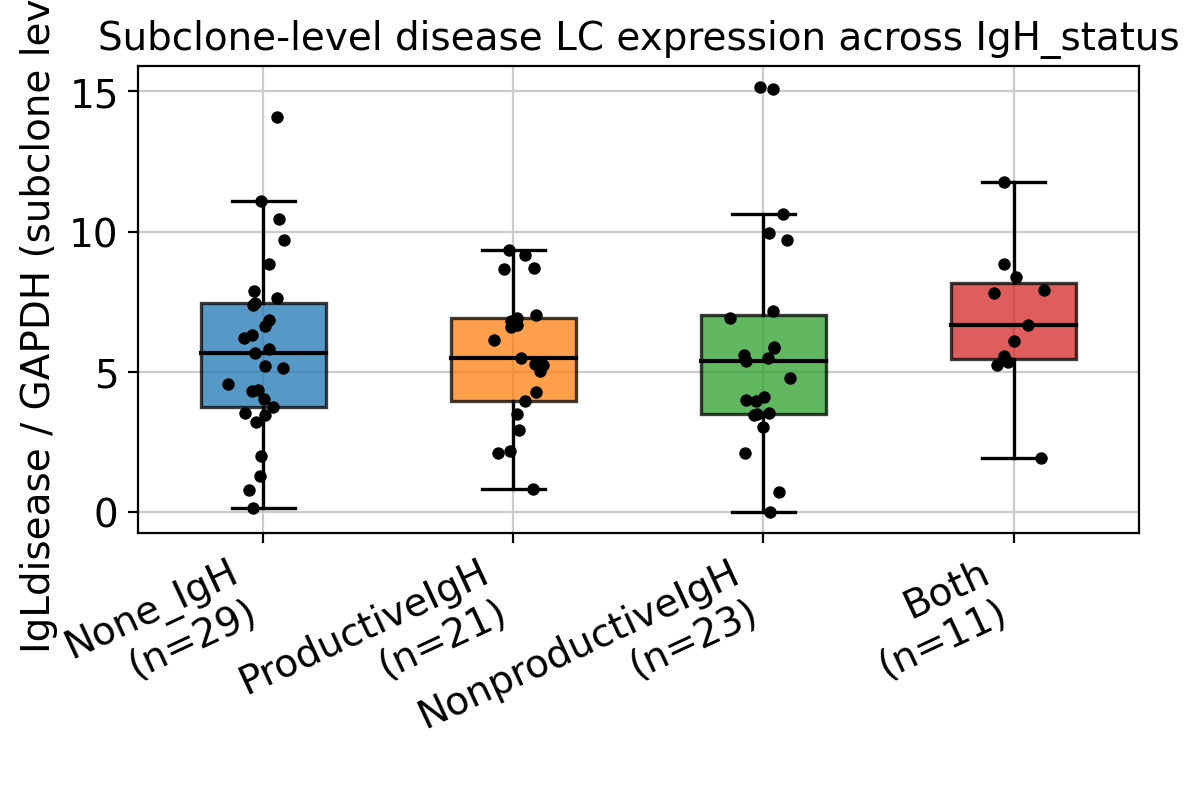

In [41]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import itertools

from scipy.stats import ranksums
from statsmodels.stats.multitest import multipletests

# ---------------------------------------
# settings
# ---------------------------------------
sample_col = "orig.ident"
clone_col = "clonotype"
group_col = "IgH_status"
out_col = "percent.igLdisease"
gapdh_gene = "GAPDH"
order = ["None_IgH", "ProductiveIgH", "NonproductiveIgH", "Both"]

# ---------------------------------------
# helper
# ---------------------------------------
def _to_1d(x):
    if sp.issparse(x):
        x = x.toarray()
    x = np.asarray(x)
    return x.ravel()

# ---------------------------------------
# gene names
# ---------------------------------------
genes = pd.Index(adata.var_names.astype(str))

# initialize output
if out_col not in adata.obs.columns:
    adata.obs[out_col] = np.nan

# total counts per cell
if "total_counts" in adata.obs.columns:
    total_counts = pd.to_numeric(adata.obs["total_counts"], errors="coerce").to_numpy()
else:
    total_counts = _to_1d(adata.X.sum(axis=1))

# ---------------------------------------
# find GAPDH
# ---------------------------------------
gapdh_matches = genes[genes.str.upper() == gapdh_gene.upper()]
if len(gapdh_matches) == 0:
    raise ValueError(f"Housekeeping gene {gapdh_gene!r} not found in adata.var_names")
if len(gapdh_matches) > 1:
    print(f"[warn] multiple {gapdh_gene} matches found: {list(gapdh_matches)}; using the first one")
gapdh_gene_use = gapdh_matches[0]

# ---------------------------------------
# step 1: keep original per-cell percent.igLdisease logic unchanged
# ---------------------------------------
dominant_gene_by_sample = {}
sample_series = adata.obs[sample_col].astype(str)

for sample in sample_series.unique():
    cell_idx = np.where(sample_series.to_numpy() == sample)[0]
    if len(cell_idx) == 0:
        continue

    if sample.startswith("ALk"):
        pattern = r"(?i)^IGKV"
    elif sample.startswith("ALl"):
        pattern = r"(?i)^IGLV"
    elif sample.startswith("HPCAL1"):
        pattern = r"(?i)^IGLV"
    elif sample.startswith("HPCAL2"):
        pattern = r"(?i)^IGKV"
    elif sample.startswith("HPCAL3"):
        pattern = r"(?i)^IGLV"
    else:
        print(f"[skip] sample {sample} does not start with ALk/ALl/HPCAL")
        continue

    matched_genes = genes[genes.str.match(pattern, na=False)]
    if len(matched_genes) == 0:
        print(f"[skip] no genes found for {sample} with pattern {pattern}")
        continue

    gene_idx = genes.get_indexer(matched_genes)
    X_sub = adata.X[cell_idx][:, gene_idx]
    gene_sums = _to_1d(X_sub.sum(axis=0))

    best_gene_pos = int(np.argmax(gene_sums))
    best_gene = matched_genes[best_gene_pos]
    dominant_gene_by_sample[sample] = best_gene

    print(f"[sample={sample}] dominant disease LC gene = {best_gene}")

    gene_counts = _to_1d(adata.X[cell_idx, genes.get_loc(best_gene)])
    pct = np.divide(
        gene_counts,
        total_counts[cell_idx],
        out=np.zeros_like(gene_counts, dtype=float),
        where=total_counts[cell_idx] != 0
    ) * 100

    adata.obs.iloc[cell_idx, adata.obs.columns.get_loc(out_col)] = pct

adata.uns["dominant_igL_disease_gene_by_sample"] = dominant_gene_by_sample

# ---------------------------------------
# step 2: build valid cell table
# ---------------------------------------
obs = adata.obs.copy()
obs[sample_col] = obs[sample_col].astype(str)

obs[clone_col] = obs[clone_col].astype("object")
bad_clone = obs[clone_col].isna() | obs[clone_col].astype(str).isin(["", "nan", "None", "NA"])
obs_valid = obs.loc[~bad_clone].copy()
obs_valid[clone_col] = obs_valid[clone_col].astype(str)

# clean group column
obs_valid[group_col] = obs_valid[group_col].astype("object")
obs_valid[group_col] = obs_valid[group_col].replace({
    "": np.nan, "nan": np.nan, "None": np.nan, "NA": np.nan
})
obs_valid = obs_valid.loc[obs_valid[group_col].notna()].copy()

valid_idx = obs_valid.index

# ---------------------------------------
# step 3: extract per-cell counts
# ---------------------------------------
obs_valid["GAPDH_counts"] = _to_1d(adata[valid_idx, gapdh_gene_use].X)

disease_counts_all = np.full(obs_valid.shape[0], np.nan, dtype=float)
disease_gene_all = np.full(obs_valid.shape[0], "", dtype=object)

valid_pos = {cell: i for i, cell in enumerate(valid_idx)}

for sample, best_gene in dominant_gene_by_sample.items():
    sub_cells = obs_valid.index[obs_valid[sample_col] == sample]
    if len(sub_cells) == 0:
        continue

    vals = _to_1d(adata[sub_cells, best_gene].X)
    pos = [valid_pos[c] for c in sub_cells]
    disease_counts_all[pos] = vals
    disease_gene_all[pos] = best_gene

obs_valid["igLdisease_counts"] = disease_counts_all
obs_valid["disease_gene_used"] = disease_gene_all

# unique clone and subclone ids
obs_valid["sample_clonotype"] = obs_valid[sample_col] + " | " + obs_valid[clone_col]
obs_valid["sample_clonotype_group"] = (
    obs_valid[sample_col] + " | " +
    obs_valid[clone_col] + " | " +
    obs_valid[group_col].astype(str)
)

print("\n[cell-level IgH_status counts in obs_valid]")
print(obs_valid[group_col].value_counts(dropna=False).reindex(order, fill_value=0))

# ---------------------------------------
# step 4: aggregate to SUBCLONE level
# ---------------------------------------
subclone_df = (
    obs_valid
    .groupby("sample_clonotype_group", observed=True)
    .agg(
        sample=(sample_col, "first"),
        clonotype=(clone_col, "first"),
        IgH_status=(group_col, "first"),
        disease_gene_used=("disease_gene_used", lambda x: x.iloc[0]),
        n_cells=(clone_col, "size"),
        igLdisease_sum=("igLdisease_counts", "sum"),
        GAPDH_sum=("GAPDH_counts", "sum"),
        percent_igLdisease_mean=(out_col, "mean"),
        percent_igLdisease_median=(out_col, "median"),
        percent_igLdisease_sum=(out_col, "sum"),
    )
    .reset_index()
    .rename(columns={"sample_clonotype_group": "subclone_id"})
)

subclone_df["igLdisease_over_GAPDH"] = np.divide(
    subclone_df["igLdisease_sum"],
    subclone_df["GAPDH_sum"],
    out=np.full(subclone_df.shape[0], np.nan, dtype=float),
    where=subclone_df["GAPDH_sum"].to_numpy() != 0
)

subclone_df["log10_igLdisease_over_GAPDH"] = np.log10(subclone_df["igLdisease_over_GAPDH"] + 1e-6)

subclone_df["IgH_status"] = pd.Categorical(
    subclone_df["IgH_status"],
    categories=order,
    ordered=True
)

print("\n[subclone-level IgH_status counts before filter]")
print(subclone_df["IgH_status"].value_counts(dropna=False).reindex(order, fill_value=0))

# ---------------------------------------
# optional filter
# ---------------------------------------
subclone_df_plot = subclone_df.loc[subclone_df["n_cells"] >= 3].copy()

print("\n[subclone-level IgH_status counts after n_cells >= 3 filter]")
print(subclone_df_plot["IgH_status"].value_counts(dropna=False).reindex(order, fill_value=0))

# save
adata.uns["subclone_level_igLdisease"] = subclone_df

# ---------------------------------------
# step 5: pairwise tests across IgH_status
# ---------------------------------------
pairs = list(itertools.combinations(order, 2))

pvals = []
labels = []

for g1, g2 in pairs:
    x = subclone_df_plot.loc[subclone_df_plot["IgH_status"] == g1, "igLdisease_over_GAPDH"].dropna()
    y = subclone_df_plot.loc[subclone_df_plot["IgH_status"] == g2, "igLdisease_over_GAPDH"].dropna()

    if len(x) >= 2 and len(y) >= 2:
        _, p = ranksums(x, y)
    else:
        p = np.nan

    pvals.append(p)
    labels.append(f"{g1} vs {g2}")

pvals = np.array(pvals, dtype=float)
pvals_adj = np.full(len(pvals), np.nan)

mask = np.isfinite(pvals)
if mask.sum() > 0:
    _, adj, _, _ = multipletests(pvals[mask], method="fdr_bh")
    pvals_adj[mask] = adj

stats_df = pd.DataFrame({
    "comparison": labels,
    "p_value": pvals,
    "BH_adj_p": pvals_adj
})

print("\n[pairwise stats]")
print(stats_df)



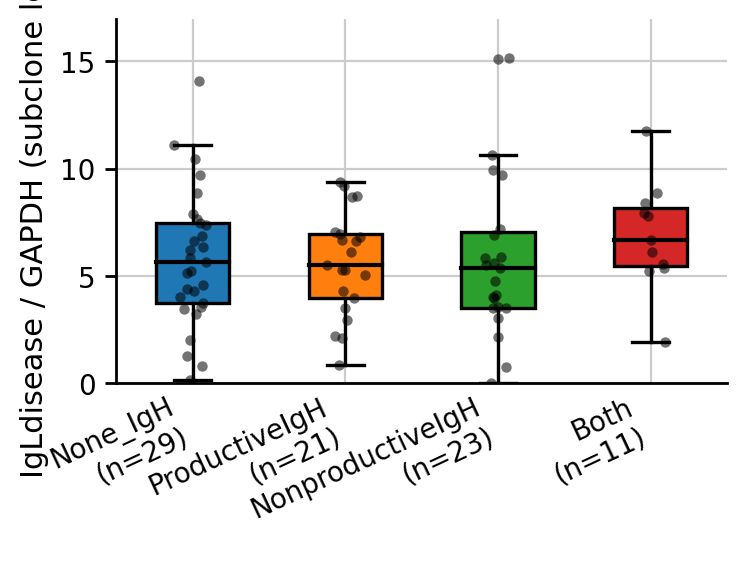

In [44]:
# ---------------------------------------
# step 6: plot (publication-style)
# ---------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# ---- optional global style ----
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 1.0,
})

fig, ax = plt.subplots(figsize=(4, 3))

data = [
    subclone_df_plot.loc[
        subclone_df_plot["IgH_status"] == g, "igLdisease_over_GAPDH"
    ].dropna().to_numpy()
    for g in order
]

labels = [f"{g}\n(n={len(v)})" for g, v in zip(order, data)]

bp = ax.boxplot(
    data,
    labels=labels,
    showfliers=False,
    patch_artist=True,
    widths=0.48,
    whis=1.5,
    medianprops=dict(color="black", linewidth=1.5),
    whiskerprops=dict(color="black", linewidth=1.2),
    capprops=dict(color="black", linewidth=1.2),
    boxprops=dict(edgecolor="black", linewidth=1.2),
)

# matplotlib 默认投稿友好颜色
box_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(1.0)

# ---- jitter points ----
rng = np.random.default_rng(123)
for i, vals in enumerate(data, start=1):
    if len(vals) == 0:
        continue
    x = rng.normal(loc=i, scale=0.055, size=len(vals))
    ax.scatter(
        x,
        vals,
        s=14,
        color="black",
        alpha=0.55,
        linewidths=0,
        zorder=3
    )

# ---- axes style ----
ax.set_ylabel("IgLdisease / GAPDH (subclone level)")
ax.set_title("", pad=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", width=1.0, length=4)

plt.setp(ax.get_xticklabels(), rotation=25, ha="right")

ax.margins(x=0.02)

# optional: slightly tighten y range if wanted
ymax = max([np.max(v) for v in data if len(v) > 0], default=1)
ax.set_ylim(bottom=0, top=ymax * 1.12)

plt.tight_layout()

# save
fig.savefig("subclone_igLdisease_over_GAPDH_boxplot_publication.pdf", bbox_inches="tight")
fig.savefig("subclone_igLdisease_over_GAPDH_boxplot_publication.png", dpi=300, bbox_inches="tight")

plt.show()

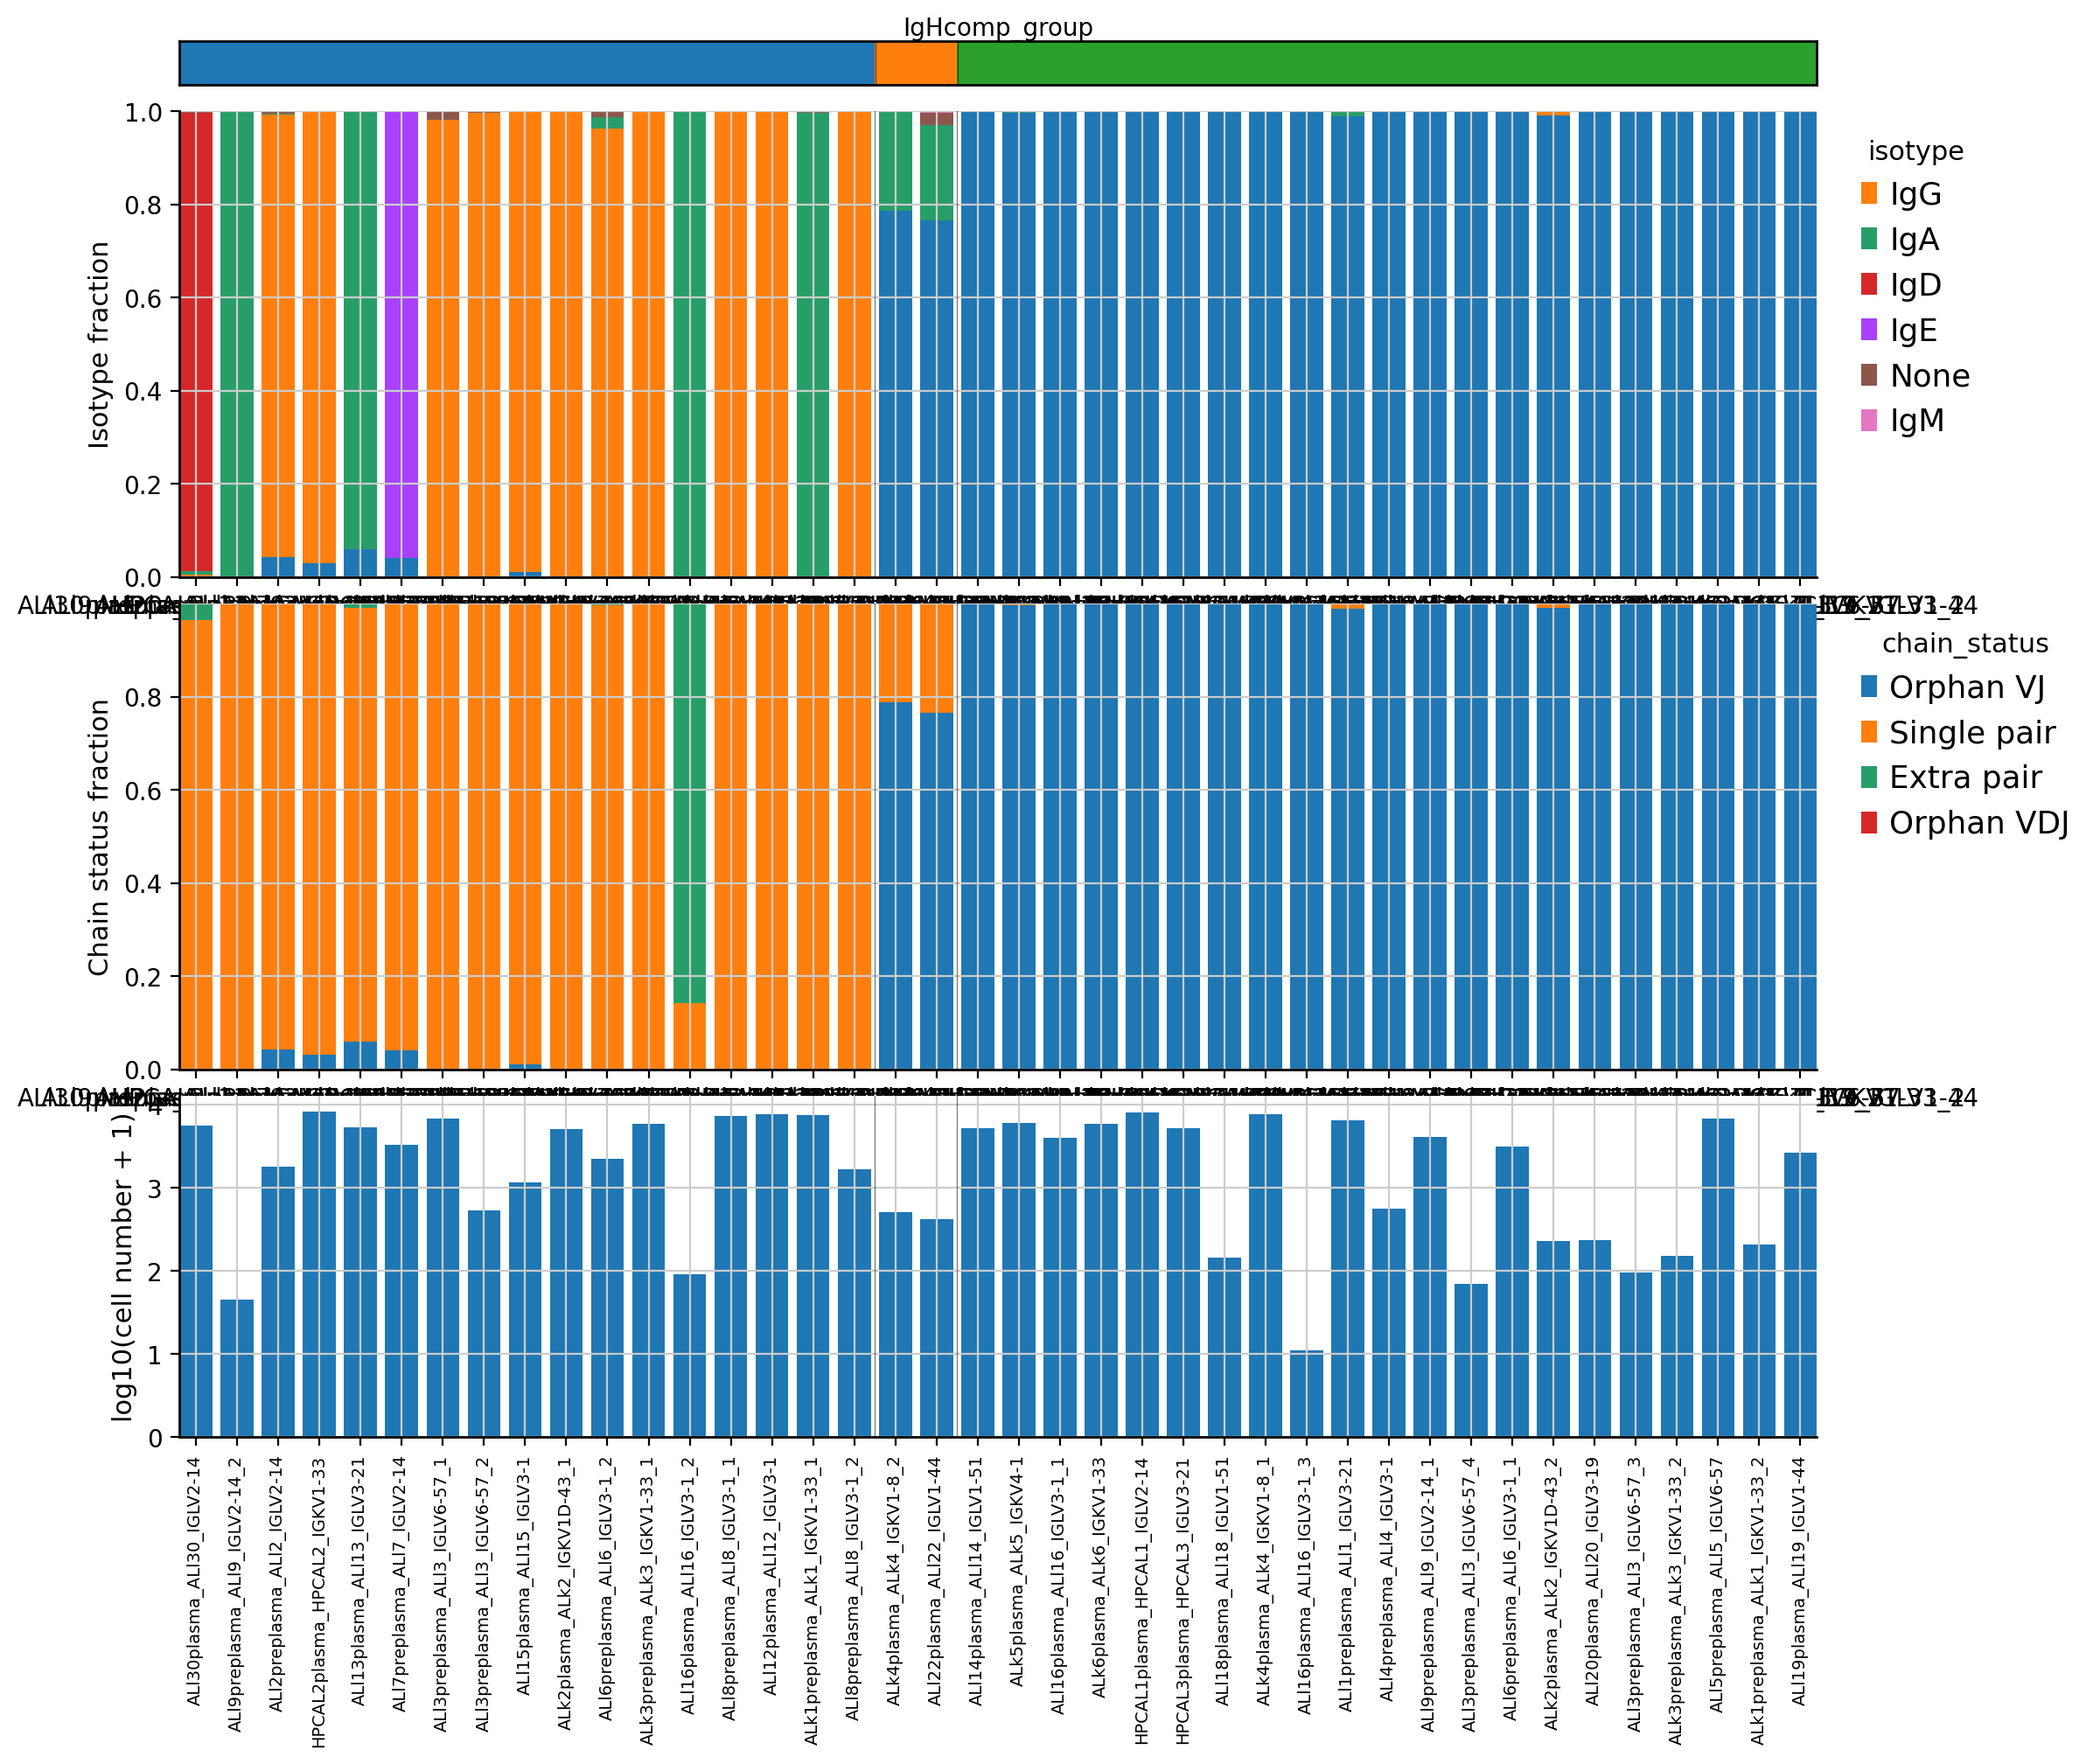

                       clonotype IgHcomp_group  cell_number  \
0     ALl30plasma_ALl30_IGLV2-14             1         5555   
1  ALl9preplasma_ALl9_IGLV2-14_2             1           44   
2    ALl2preplasma_ALl2_IGLV2-14             1         1801   
3   HPCAL2plasma_HPCAL2_IGKV1-33             1         8152   
4     ALl13plasma_ALl13_IGLV3-21             1         5345   

   log10_cell_number_plus1  
0                 3.744762  
1                 1.653213  
2                 3.255755  
3                 3.911317  
4                 3.728029  


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# USER SETTINGS
# =========================================================
CLONO = "clonotype"
GROUP = "IgHcomp_group"      # already written back to adata.obs in your previous code
ISOTYPE = "isotype"          # <- change to your actual column
CHAIN_STATUS = "chain_status"  # <- change to your actual column

# if you want to force category order, fill these; otherwise None = auto by mean fraction
isotype_order = None
chain_order = None

# =========================================================
# 0) start from adata.obs and KEEP the same clonotype order
# =========================================================
obs = adata.obs.copy()

# make sure ordered_clonos already exists from your previous clustering code
# if not, use current order in comp_props_ord.index as fallback
if "ordered_clonos" not in globals():
    if "comp_props_ord" in globals():
        ordered_clonos = comp_props_ord.index.tolist()
    else:
        raise ValueError("ordered_clonos not found. Please run your previous clustering/order code first.")

obs = obs[[CLONO, GROUP, ISOTYPE, CHAIN_STATUS]].copy()
obs = obs.dropna(subset=[CLONO])
obs[CLONO] = obs[CLONO].astype(str)

# keep only clonotypes in the same order
obs = obs[obs[CLONO].isin(ordered_clonos)].copy()

# =========================================================
# 1) cell number per clonotype
# =========================================================
cell_counts = obs[CLONO].value_counts().reindex(ordered_clonos).fillna(0).astype(int)
log_counts = np.log10(cell_counts + 1)

# =========================================================
# 2) isotype fraction matrix
# =========================================================
iso_obs = obs.dropna(subset=[ISOTYPE]).copy()
iso_obs[ISOTYPE] = iso_obs[ISOTYPE].astype(str)

iso_counts = pd.crosstab(iso_obs[CLONO], iso_obs[ISOTYPE]).reindex(ordered_clonos, fill_value=0)
iso_props = iso_counts.div(iso_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

if isotype_order is None:
    isotype_order = iso_props.mean(axis=0).sort_values(ascending=False).index.tolist()
iso_props = iso_props.reindex(columns=[c for c in isotype_order if c in iso_props.columns])

# =========================================================
# 3) chain status fraction matrix
# =========================================================
chain_obs = obs.dropna(subset=[CHAIN_STATUS]).copy()
chain_obs[CHAIN_STATUS] = chain_obs[CHAIN_STATUS].astype(str)

chain_counts = pd.crosstab(chain_obs[CLONO], chain_obs[CHAIN_STATUS]).reindex(ordered_clonos, fill_value=0)
chain_props = chain_counts.div(chain_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

if chain_order is None:
    chain_order = chain_props.mean(axis=0).sort_values(ascending=False).index.tolist()
chain_props = chain_props.reindex(columns=[c for c in chain_order if c in chain_props.columns])

# =========================================================
# 4) group strip info
# =========================================================
# clonotype -> group
grp_series = (
    obs[[CLONO, GROUP]]
    .dropna(subset=[GROUP])
    .drop_duplicates(subset=[CLONO])
    .set_index(CLONO)[GROUP]
    .reindex(ordered_clonos)
)

grp = grp_series.to_numpy()

# auto colors for group strip
cmap_grp = plt.get_cmap("tab10")
grp_colors = []
for g in grp:
    if pd.isna(g):
        grp_colors.append((0.9, 0.9, 0.9, 1.0))
    else:
        grp_colors.append(cmap_grp((int(g) - 1) % 10))
grp_colors = np.array(grp_colors)

# boundaries between groups
grp_num = pd.Series(grp).fillna(-999).to_numpy()
boundaries = np.where(grp_num[:-1] != grp_num[1:])[0]

# =========================================================
# 5) plot
# =========================================================
n_clono = len(ordered_clonos)
x = np.arange(n_clono)

fig_w = max(12, 0.22 * n_clono)
fig_h = 10.5

fig = plt.figure(figsize=(fig_w, fig_h))
gs = fig.add_gridspec(
    nrows=4, ncols=1,
    height_ratios=[0.28, 3.0, 3.0, 2.2],
    hspace=0.08
)

ax_strip = fig.add_subplot(gs[0, 0])
ax_iso   = fig.add_subplot(gs[1, 0])
ax_chain = fig.add_subplot(gs[2, 0], sharex=ax_iso)
ax_n     = fig.add_subplot(gs[3, 0], sharex=ax_iso)

# -------------------------
# top strip: IgHcomp_group
# -------------------------
ax_strip.imshow(grp_colors[np.newaxis, :, :], aspect="auto")
ax_strip.set_yticks([])
ax_strip.set_xticks([])
ax_strip.set_xlim(-0.5, n_clono - 0.5)
ax_strip.set_title("IgHcomp_group", fontsize=10, pad=2)

for b in boundaries:
    ax_strip.axvline(b + 0.5, color="k", linewidth=0.5, alpha=0.5)

# -------------------------
# panel 1: isotype fraction
# -------------------------
bottom = np.zeros(n_clono)
for s in iso_props.columns:
    vals = iso_props[s].to_numpy()
    ax_iso.bar(x, vals, bottom=bottom, label=s, linewidth=0)
    bottom += vals

ax_iso.set_ylim(0, 1)
ax_iso.set_ylabel("Isotype fraction")
ax_iso.set_xticks([])

for b in boundaries:
    ax_iso.axvline(b + 0.5, color="k", linewidth=0.5, alpha=0.5)

ax_iso.legend(
    title=ISOTYPE,
    frameon=False,
    bbox_to_anchor=(1.01, 1),
    loc="upper left"
)

# -------------------------
# panel 2: chain status fraction
# -------------------------
bottom = np.zeros(n_clono)
for s in chain_props.columns:
    vals = chain_props[s].to_numpy()
    ax_chain.bar(x, vals, bottom=bottom, label=s, linewidth=0)
    bottom += vals

ax_chain.set_ylim(0, 1)
ax_chain.set_ylabel("Chain status fraction")
ax_chain.set_xticks([])

for b in boundaries:
    ax_chain.axvline(b + 0.5, color="k", linewidth=0.5, alpha=0.5)

ax_chain.legend(
    title=CHAIN_STATUS,
    frameon=False,
    bbox_to_anchor=(1.01, 1),
    loc="upper left"
)

# -------------------------
# panel 3: log10(cell number + 1)
# -------------------------
ax_n.bar(x, log_counts.to_numpy(), linewidth=0)
ax_n.set_ylabel("log10(cell number + 1)")
ax_n.set_xticks(x)
ax_n.set_xticklabels(ordered_clonos, rotation=90, fontsize=7)
ax_n.margins(x=0)

for b in boundaries:
    ax_n.axvline(b + 0.5, color="k", linewidth=0.5, alpha=0.5)

# style cleanup
for ax in [ax_iso, ax_chain, ax_n]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# optional summary
plot_df = pd.DataFrame({
    "clonotype": ordered_clonos,
    "IgHcomp_group": grp,
    "cell_number": cell_counts.reindex(ordered_clonos).to_numpy(),
    "log10_cell_number_plus1": log_counts.reindex(ordered_clonos).to_numpy(),
})
print(plot_df.head())

## 5. USER SETTINGS


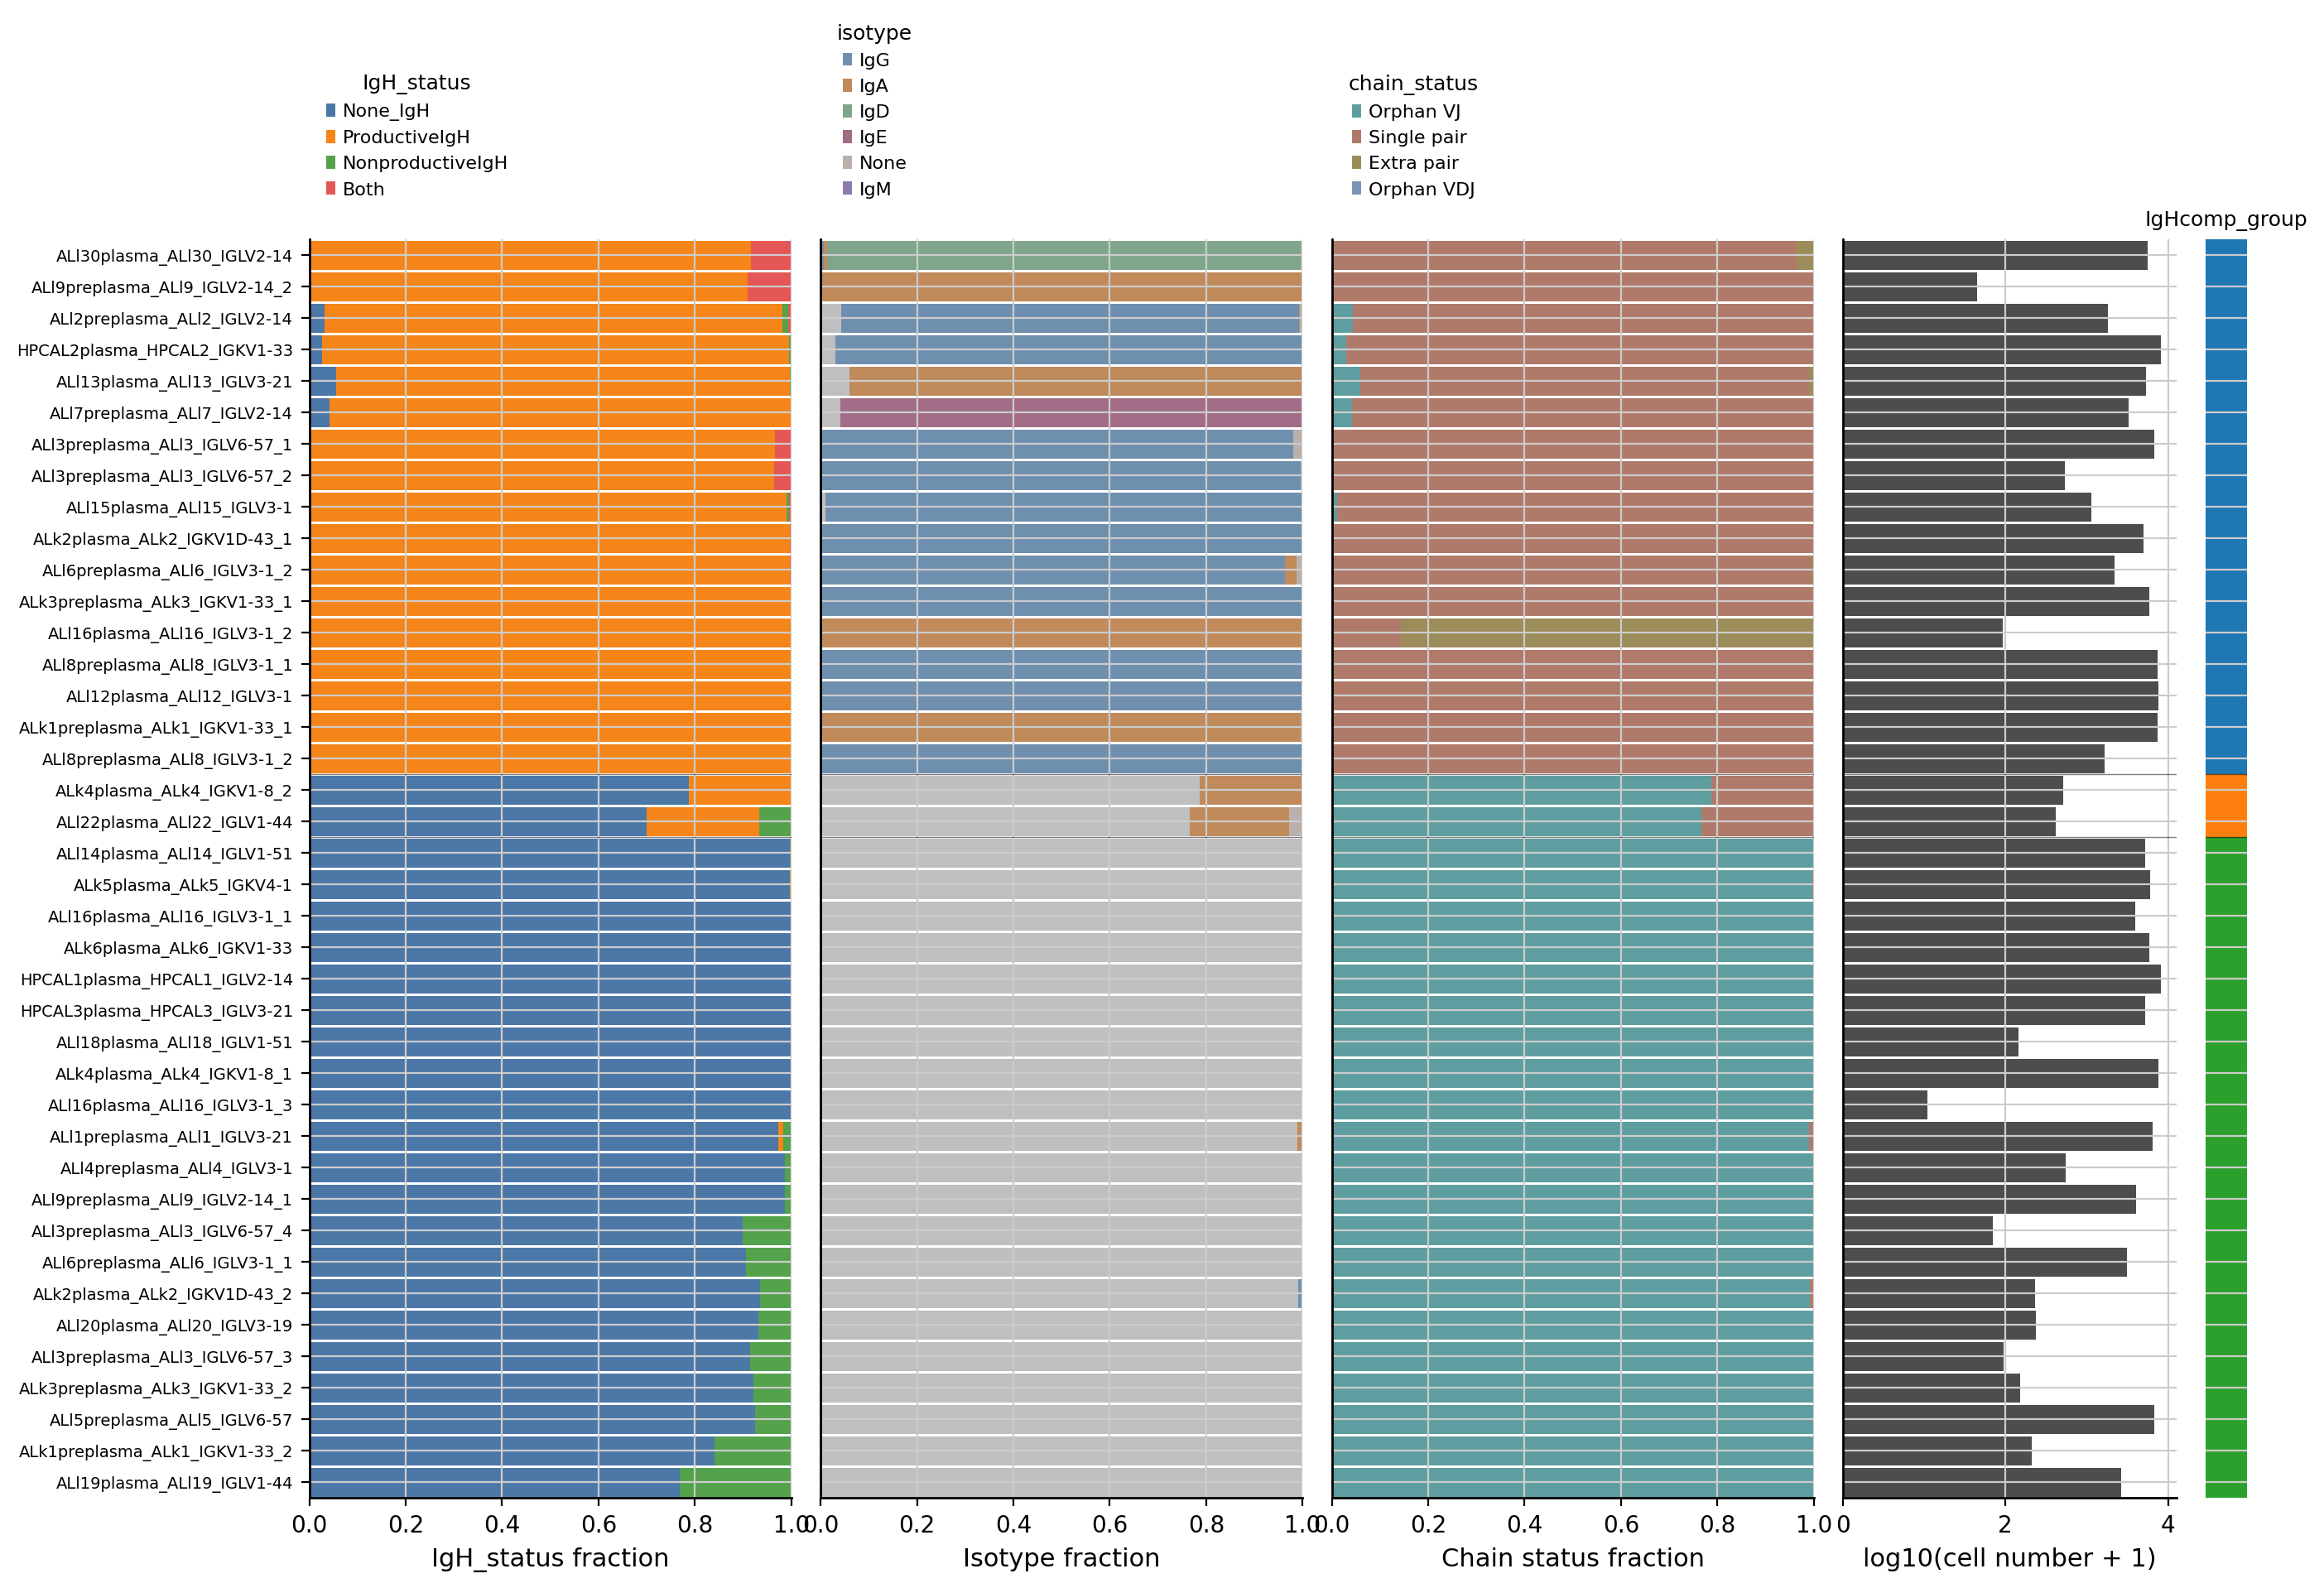

Saved: clonotype_rotated_90deg_bar_right.pdf


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# USER SETTINGS
# =========================================================
CLONO = "clonotype"
GROUP = "IgHcomp_group"
IGH_STATUS = "IgH_status"
ISOTYPE = "isotype"
CHAIN_STATUS = "chain_status"

igh_status_order = ["None_IgH", "ProductiveIgH", "NonproductiveIgH", "Both"]
isotype_order = None
chain_order = None

# =========================================================
# palettes
# =========================================================
# palettes
# =========================================================
iso_palette = {
    "IgG":  "#6F8FAF",  # muted slate blue
    "IgA":  "#C08A5B",  # muted ochre
    "IgD":  "#7FA58A",  # muted sage
    "IgE":  "#A06C86",  # muted rose-plum
    "IgM":  "#8C7BAF",  # dusty violet
    "None": "#BAB0AC",
    "NA":   "#BAB0AC",
}

cs_palette = {
    "Orphan VJ":   "#5F9EA0",  # muted teal
    "Single pair": "#B07A6A",  # muted clay
    "Extra pair":  "#9C8C5A",  # muted olive-brown
    "Orphan VDJ":  "#7C94B6",  # soft steel blue
    "None":        "#B8B8B8",
    "NA":          "#B8B8B8",
}

igh_status_palette = {
    "None_IgH":           "#4C78A8",
    "ProductiveIgH":      "#F58518",
    "NonproductiveIgH":   "#54A24B",
    "Both":               "#E45756",
    "NA":                 "#BAB0AC",
}
# =========================================================
# 0) base obs, KEEP the same clonotype order
# =========================================================
if "ordered_clonos" not in globals():
    if "comp_props_ord" in globals():
        ordered_clonos = comp_props_ord.index.tolist()
    else:
        raise ValueError("ordered_clonos not found. Please run the previous clustering/order code first.")

obs = adata.obs.copy()
need_cols = [CLONO, GROUP, IGH_STATUS, ISOTYPE, CHAIN_STATUS]
missing = [c for c in need_cols if c not in obs.columns]
if len(missing) > 0:
    raise ValueError(f"Missing columns in adata.obs: {missing}")

obs = obs[need_cols].copy()
obs = obs.dropna(subset=[CLONO])
obs[CLONO] = obs[CLONO].astype(str)
obs = obs[obs[CLONO].isin(ordered_clonos)].copy()

for col in [IGH_STATUS, ISOTYPE, CHAIN_STATUS]:
    obs[col] = obs[col].astype("object").where(~obs[col].isna(), "NA").astype(str)

# =========================================================
# 1) cell number per clonotype
# =========================================================
cell_counts = obs[CLONO].value_counts().reindex(ordered_clonos).fillna(0).astype(int)
log_counts = np.log10(cell_counts + 1)

# =========================================================
# 2) IgH_status fraction
# =========================================================
igh_counts = pd.crosstab(obs[CLONO], obs[IGH_STATUS]).reindex(ordered_clonos, fill_value=0)
igh_props = igh_counts.div(igh_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

if igh_status_order is None:
    igh_status_order = igh_props.mean(axis=0).sort_values(ascending=False).index.tolist()
else:
    igh_status_order = [c for c in igh_status_order if c in igh_props.columns] + \
                       [c for c in igh_props.columns if c not in igh_status_order]
igh_props = igh_props[igh_status_order]

# =========================================================
# 3) isotype fraction
# =========================================================
iso_counts = pd.crosstab(obs[CLONO], obs[ISOTYPE]).reindex(ordered_clonos, fill_value=0)
iso_props = iso_counts.div(iso_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

if isotype_order is None:
    isotype_order = iso_props.mean(axis=0).sort_values(ascending=False).index.tolist()
else:
    isotype_order = [c for c in isotype_order if c in iso_props.columns] + \
                    [c for c in iso_props.columns if c not in isotype_order]
iso_props = iso_props[isotype_order]

# =========================================================
# 4) chain status fraction
# =========================================================
chain_counts = pd.crosstab(obs[CLONO], obs[CHAIN_STATUS]).reindex(ordered_clonos, fill_value=0)
chain_props = chain_counts.div(chain_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

if chain_order is None:
    chain_order = chain_props.mean(axis=0).sort_values(ascending=False).index.tolist()
else:
    chain_order = [c for c in chain_order if c in chain_order if c in chain_props.columns] + \
                  [c for c in chain_props.columns if c not in chain_order]
chain_props = chain_props[chain_order]

# =========================================================
# 5) group strip
# =========================================================
grp_series = (
    obs[[CLONO, GROUP]]
    .dropna(subset=[GROUP])
    .drop_duplicates(subset=[CLONO])
    .set_index(CLONO)[GROUP]
    .reindex(ordered_clonos)
)

grp = grp_series.to_numpy()

cmap_grp = plt.get_cmap("tab10")
grp_colors = []
for g in grp:
    if pd.isna(g):
        grp_colors.append((0.9, 0.9, 0.9, 1.0))
    else:
        grp_colors.append(cmap_grp((int(g) - 1) % 10))
grp_colors = np.array(grp_colors)

grp_num = pd.Series(grp).fillna(-999).to_numpy()
boundaries = np.where(grp_num[:-1] != grp_num[1:])[0]

# =========================================================
# 6) plot (rotated 90 degrees)
# =========================================================
n_clono = len(ordered_clonos)
y = np.arange(n_clono)

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

fig_h = max(10, 0.22 * n_clono)
fig_w = 15

fig = plt.figure(figsize=(fig_w, fig_h))
gs = fig.add_gridspec(
    nrows=1, ncols=5,
    width_ratios=[2.6, 2.6, 2.6, 1.8, 0.22],
    wspace=0.08
)

ax_igh   = fig.add_subplot(gs[0, 0])
ax_iso   = fig.add_subplot(gs[0, 1], sharey=ax_igh)
ax_chain = fig.add_subplot(gs[0, 2], sharey=ax_igh)
ax_n     = fig.add_subplot(gs[0, 3], sharey=ax_igh)
ax_strip = fig.add_subplot(gs[0, 4], sharey=ax_igh)

# -------------------------
# IgH_status fraction
# -------------------------
left = np.zeros(n_clono)
for s in igh_props.columns:
    vals = igh_props[s].to_numpy()
    ax_igh.barh(
        y, vals, left=left, height=0.9, linewidth=0,
        color=igh_status_palette.get(s, (0.75, 0.75, 0.75, 1.0)),
        label=s
    )
    left += vals

ax_igh.set_xlim(0, 1)
ax_igh.set_xlabel("IgH_status fraction")
ax_igh.set_yticks(y)
ax_igh.set_yticklabels(ordered_clonos, fontsize=7)
ax_igh.invert_yaxis()

for b in boundaries:
    ax_igh.axhline(b + 0.5, color="k", linewidth=0.5, alpha=0.5)

ax_igh.legend(
    title=IGH_STATUS,
    frameon=False,
    bbox_to_anchor=(0.0, 1.02),
    loc="lower left",
    fontsize=8,
    title_fontsize=9
)

# -------------------------
# isotype fraction
# -------------------------
left = np.zeros(n_clono)
for iso in iso_props.columns:
    vals = iso_props[iso].to_numpy()
    ax_iso.barh(
        y, vals, left=left, height=0.9, linewidth=0,
        color=iso_palette.get(iso, (0.75, 0.75, 0.75, 1.0)),
        label=iso
    )
    left += vals

ax_iso.set_xlim(0, 1)
ax_iso.set_xlabel("Isotype fraction")

for b in boundaries:
    ax_iso.axhline(b + 0.5, color="k", linewidth=0.5, alpha=0.5)

ax_iso.legend(
    title=ISOTYPE,
    frameon=False,
    bbox_to_anchor=(0.0, 1.02),
    loc="lower left",
    fontsize=8,
    title_fontsize=9
)

# -------------------------
# chain status fraction
# -------------------------
left = np.zeros(n_clono)
for cs in chain_props.columns:
    vals = chain_props[cs].to_numpy()
    ax_chain.barh(
        y, vals, left=left, height=0.9, linewidth=0,
        color=cs_palette.get(cs, (0.75, 0.75, 0.75, 1.0)),
        label=cs
    )
    left += vals

ax_chain.set_xlim(0, 1)
ax_chain.set_xlabel("Chain status fraction")

for b in boundaries:
    ax_chain.axhline(b + 0.5, color="k", linewidth=0.5, alpha=0.5)

ax_chain.legend(
    title=CHAIN_STATUS,
    frameon=False,
    bbox_to_anchor=(0.0, 1.02),
    loc="lower left",
    fontsize=8,
    title_fontsize=9
)

# -------------------------
# log10(cell number + 1) at right
# -------------------------
ax_n.barh(y, log_counts.to_numpy(), height=0.9, linewidth=0, color="#4D4D4D")
ax_n.set_xlabel("log10(cell number + 1)")

for b in boundaries:
    ax_n.axhline(b + 0.5, color="k", linewidth=0.5, alpha=0.5)

# -------------------------
# group strip at far right
# -------------------------
# shape should be (n_clono, 1, 4)
ax_strip.imshow(grp_colors[:, np.newaxis, :], aspect="auto", origin="upper")
ax_strip.set_xticks([])
ax_strip.set_yticks(y)
ax_strip.set_yticklabels(ordered_clonos, fontsize=7)
ax_strip.yaxis.tick_right()
ax_strip.tick_params(axis="y", labelright=False, labelleft=False, length=0, pad=3)
ax_strip.set_title("IgHcomp_group", fontsize=9, pad=6)

for spine in ["top", "bottom", "left", "right"]:
    ax_strip.spines[spine].set_visible(False)
for b in boundaries:
    ax_strip.axhline(b + 0.5, color="k", linewidth=0.5, alpha=0.5)

# -------------------------
# cleanup
# -------------------------
for ax in [ax_igh, ax_iso, ax_chain, ax_n]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax in [ax_iso, ax_chain, ax_n]:
    plt.setp(ax.get_yticklabels(), visible=False)
    ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

fig.savefig("clonotype_rotated_90deg_bar_right.pdf", dpi=300, bbox_inches="tight")
print("Saved: clonotype_rotated_90deg_bar_right.pdf")